In [1]:
%matplotlib inline

import os
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


In [2]:
# ── Config — must match nn_toy_1192k_h2o_infer.py exactly ────────────────────
YAML_FILE   = 'chem_cti_toy_model_og.yaml'
IDX_R22     = 21
IDX_R26     = 25
INPUT_DIM   = 4
PARAM_NAMES = ['lnA_R22', 'Ea_R22', 'lnA_R26', 'Ea_R26']
LN_F        = 10
SIGMA_E     = 5000.0
HIDDEN_DIM  = 16
LOG_EPS     = 1e-12

# Zhang Eq. 8 hyperparameters
LAMBDA      = 4.0
NOISE_FLOOR = 1e-12
SIGMA_OB_LN = 0.05

T_INITIAL  = 1192
P_INITIAL  = 1.95 * ct.one_atm
INITIAL_X  = {'H2O2': 2216e-6, 'H2O': 1364e-6, 'O2': 682e-6,
               'AR':   1.0 - (2216 + 1364 + 682) * 1e-6}

# Fixed-step grid for H2O profile (matches training)
DT_SIM   = 1e-6
N_STEPS  = 1000
T_SIM    = np.linspace(DT_SIM, DT_SIM * N_STEPS, N_STEPS)  # 1 µs … 1 ms

# Fine grid for OH profile (dense near peak, sparser afterwards)
T_OH = np.concatenate([
    np.linspace(1e-7, 2e-4, 600),          # 0.1 µs … 0.2 ms — captures peak
    np.linspace(2e-4 + 5e-6, 1e-3, 200),   # 0.2 ms … 1 ms
])

RESULT_PATH = 'result_1192k_h2o_train.pt'
H2O_CSV     = 'hong_1192K_h2o.csv'
OH_CSV      = 'hong_1192K_oh.csv'


In [3]:
# ── Nominal rate constants ────────────────────────────────────────────────────
_gas = ct.Solution(YAML_FILE)
_mol = ct.UnitSystem({
    'length': 'cm', 'mass': 'g', 'time': 's',
    'quantity': 'mol', 'pressure': 'dyn / cm^2', 'energy': 'erg',
    'temperature': 'K', 'current': 'A', 'activation-energy': 'cal / mol'})

NOMINAL_A_R22      = _gas.reaction(IDX_R22).rate.low_rate.pre_exponential_factor
NOMINAL_B_R22      = _gas.reaction(IDX_R22).rate.low_rate.temperature_exponent
NOMINAL_EA_R22_si  = _gas.reaction(IDX_R22).rate.low_rate.activation_energy
NOMINAL_EA_R22_cal = _mol.convert_activation_energy_to(
    f'{NOMINAL_EA_R22_si} J/kmol', 'cal / mol')

NOMINAL_A_R26      = _gas.reaction(IDX_R26).rate.pre_exponential_factor
NOMINAL_B_R26      = _gas.reaction(IDX_R26).rate.temperature_exponent
NOMINAL_EA_R26_si  = _gas.reaction(IDX_R26).rate.activation_energy
NOMINAL_EA_R26_cal = _mol.convert_activation_energy_to(
    f'{NOMINAL_EA_R26_si} J/kmol', 'cal / mol')
del _gas, _mol

print(f'R22  A={NOMINAL_A_R22:.3e}  B={NOMINAL_B_R22:.2f}  Ea={NOMINAL_EA_R22_cal:.0f} cal/mol')
print(f'R26  A={NOMINAL_A_R26:.3e}  B={NOMINAL_B_R26:.2f}  Ea={NOMINAL_EA_R26_cal:.0f} cal/mol')


R22  A=2.490e+21  B=-2.30  Ea=48749 cal/mol
R26  A=7.590e+10  B=0.00  Ea=7270 cal/mol


In [4]:
# ── Experimental data ─────────────────────────────────────────────────────────
df_h2o = pd.read_csv(H2O_CSV, skipinitialspace=True)   # "Time [ms]", "[H2O] ppm"
df_oh  = pd.read_csv(OH_CSV,  skipinitialspace=True)   # "Time [ms]", "[OH] ppm"

# Keep raw scatter for plotting; aggregate per unique time for interpolation
t_h2o_raw = df_h2o['Time [ms]'].values
y_h2o_raw = df_h2o['[H2O] ppm'].values

t_oh_raw  = df_oh['Time [ms]'].values
y_oh_raw  = df_oh['[OH] ppm'].values

h2o_agg = df_h2o.groupby('Time [ms]')['[H2O] ppm'].mean().reset_index()
t_h2o   = h2o_agg['Time [ms]'].values * 1e-3   # ms → s
y_h2o   = h2o_agg['[H2O] ppm'].values * 1e-6   # ppm → mole fraction

oh_agg  = df_oh.groupby('Time [ms]')['[OH] ppm'].mean().reset_index()
t_oh    = oh_agg['Time [ms]'].values * 1e-3
y_oh    = oh_agg['[OH] ppm'].values             # keep ppm for plotting

print(f'\nH2O exp: {len(df_h2o)} raw pts, {len(t_h2o)} unique times, '
      f't=[{t_h2o.min()*1e3:.3f}, {t_h2o.max()*1e3:.3f}] ms, '
      f'H2O=[{y_h2o.min()*1e6:.0f}, {y_h2o.max()*1e6:.0f}] ppm')
print(f'OH  exp: {len(df_oh)} raw pts, {len(t_oh)} unique times, '
      f't=[{t_oh.min()*1e3:.4f}, {t_oh.max()*1e3:.4f}] ms, '
      f'OH=[{y_oh.min():.1f}, {y_oh.max():.1f}] ppm')



H2O exp: 401 raw pts, 401 unique times, t=[0.001, 1.000] ms, H2O=[1300, 3673] ppm
OH  exp: 62 raw pts, 62 unique times, t=[-0.0049, 0.9757] ms, OH=[-0.0, 65.4] ppm


In [5]:
# ── Load surrogate model ──────────────────────────────────────────────────────
class SurrogateNN(nn.Module):
    def __init__(self, hidden=HIDDEN_DIM, n_out=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_out),
        )

    def forward(self, x):
        return self.net(x)


bundle       = torch.load(RESULT_PATH, weights_only=False)
TARGET_TIMES = bundle['target_times']
N_TARGETS    = len(TARGET_TIMES)
model        = SurrogateNN(n_out=N_TARGETS)
model.load_state_dict(bundle['model_state'])
model.eval()

print(f'\nLoaded: {RESULT_PATH}')
print(f'N_TARGETS={N_TARGETS}, times (ms): {(TARGET_TIMES * 1e3).round(3)}')

# Experimental H2O interpolated at the surrogate's target times
y_exp_at_targets = np.interp(TARGET_TIMES, t_h2o, y_h2o)
log_y_exp        = np.log(np.clip(y_exp_at_targets + LOG_EPS, NOISE_FLOOR, None))

print('\nExp H2O at target times:')
for t, ye in zip(TARGET_TIMES * 1e3, y_exp_at_targets * 1e6):
    print(f'  t={t:.3f} ms   H2O_exp={ye:.1f} ppm')



Loaded: result_1192k_h2o_train.pt
N_TARGETS=5, times (ms): [0.034 0.07  0.121 0.206 0.374]

Exp H2O at target times:
  t=0.034 ms   H2O_exp=1762.3 ppm
  t=0.070 ms   H2O_exp=2271.9 ppm
  t=0.121 ms   H2O_exp=2758.8 ppm
  t=0.206 ms   H2O_exp=3161.8 ppm
  t=0.374 ms   H2O_exp=3342.2 ppm


In [6]:
# ── NN forward and Jacobian ───────────────────────────────────────────────────
def nn_raw(x_vec):
    x_t = torch.tensor(np.asarray(x_vec).reshape(1, -1), dtype=torch.float32)
    with torch.no_grad():
        return model(x_t).squeeze(0).numpy()


def nn_jacobian(x_vec):
    x_t = torch.tensor(np.asarray(x_vec).reshape(1, -1),
                        dtype=torch.float32, requires_grad=True)
    J = torch.autograd.functional.jacobian(
            lambda xx: model(xx).squeeze(0), x_t)
    return J.detach().numpy().reshape(N_TARGETS, INPUT_DIM)


In [7]:
# ── Zhang Eq. 8 objective (NN-MSI + L2 regularisation) ───────────────────────
def objective(x_vec):
    data_res = (nn_raw(x_vec) - log_y_exp) / SIGMA_OB_LN
    reg_res  = np.sqrt(LAMBDA) * np.asarray(x_vec)
    return np.concatenate([data_res, reg_res])


def objective_jac(x_vec):
    J_data = nn_jacobian(x_vec) / SIGMA_OB_LN
    J_reg  = np.sqrt(LAMBDA) * np.eye(INPUT_DIM)
    return np.vstack([J_data, J_reg])


# Jacobian sanity check
_xc  = np.array([0.10, -0.10, 0.05, -0.05])
_r0  = objective(_xc)
_Ja  = objective_jac(_xc)
_Jn  = np.zeros_like(_Ja)
_eps = 1e-5
for _j in range(INPUT_DIM):
    _dx = np.zeros(INPUT_DIM); _dx[_j] = _eps
    _Jn[:, _j] = (objective(_xc + _dx) - _r0) / _eps
_rel = np.abs(_Ja - _Jn).max() / (np.abs(_Jn).max() + 1e-12)
print(f'\nJacobian check (analytic vs FD): max rel err = {_rel:.2e}  '
      f'[{"OK" if _rel < 0.1 else "RE-CHECK"}]')



Jacobian check (analytic vs FD): max rel err = 2.90e-02  [OK]


In [8]:
# ── TRF optimisation ──────────────────────────────────────────────────────────
print('\nOptimizing (Zhang Eq. 8, NN-MSI)...')
result = least_squares(
    objective, np.zeros(INPUT_DIM),
    jac=objective_jac,
    bounds=([-1.0] * INPUT_DIM, [1.0] * INPUT_DIM),
    method='trf',
    verbose=1)
x_opt = result.x

print(f'\nConverged: {result.success}  (status {result.status}: {result.message})')
for name, xv in zip(PARAM_NAMES, x_opt):
    flag = '  <-- AT BOUND' if abs(abs(xv) - 1.0) < 1e-4 else ''
    print(f'  {name:12s}: x* = {xv:+.8f}{flag}')
print(f'Final cost 0.5‖r‖² = {result.cost:.4e}')



Optimizing (Zhang Eq. 8, NN-MSI)...
`xtol` termination condition is satisfied.
Function evaluations 10, initial cost 6.6434e-01, final cost 6.6336e-01, first-order optimality 4.80e-04.

Converged: True  (status 3: `xtol` termination condition is satisfied.)
  lnA_R22     : x* = +0.00007389
  Ea_R22      : x* = -0.00002750
  lnA_R26     : x* = +0.01814597
  Ea_R26      : x* = -0.00342821
Final cost 0.5‖r‖² = 6.6336e-01


In [9]:
# ── Laplace posterior (Gauss-Newton Hessian) ──────────────────────────────────
H_gn       = result.jac.T @ result.jac
Sigma_star = np.linalg.inv(H_gn)
L_chol     = np.linalg.cholesky(Sigma_star)

J_opt    = nn_jacobian(x_opt)
pred_var = np.sum((J_opt @ L_chol) ** 2, axis=1)
pred_std = np.sqrt(pred_var)

phys_scales   = np.array([LN_F, SIGMA_E, LN_F, SIGMA_E])
post_std_phys = np.sqrt(np.diag(Sigma_star)) * phys_scales

A_R22_opt  = NOMINAL_A_R22 * np.exp(x_opt[0] * LN_F)
Ea_R22_opt = NOMINAL_EA_R22_cal + x_opt[1] * SIGMA_E
A_R26_opt  = NOMINAL_A_R26 * np.exp(x_opt[2] * LN_F)
Ea_R26_opt = NOMINAL_EA_R26_cal + x_opt[3] * SIGMA_E

print('\n' + '='*72)
print('  Optimized rate parameters:')
print(f'  R22  A:  nom={NOMINAL_A_R22:.3e}  opt={A_R22_opt:.3e}  '
      f'x*={x_opt[0]:+.4f}  2σ: ×÷{np.exp(2*post_std_phys[0]):.2f}')
print(f'       Ea: nom={NOMINAL_EA_R22_cal:.0f}  opt={Ea_R22_opt:.0f} cal/mol  '
      f'x*={x_opt[1]:+.4f}  2σ: ±{2*post_std_phys[1]:.0f} cal/mol')
print(f'  R26  A:  nom={NOMINAL_A_R26:.3e}  opt={A_R26_opt:.3e}  '
      f'x*={x_opt[2]:+.4f}  2σ: ×÷{np.exp(2*post_std_phys[2]):.2f}')
print(f'       Ea: nom={NOMINAL_EA_R26_cal:.0f}  opt={Ea_R26_opt:.0f} cal/mol  '
      f'x*={x_opt[3]:+.4f}  2σ: ±{2*post_std_phys[3]:.0f} cal/mol')
print('='*72)



  Optimized rate parameters:
  R22  A:  nom=2.490e+21  opt=2.492e+21  x*=+0.0001  2σ: ×÷7.93
       Ea: nom=48749  opt=48749 cal/mol  x*=-0.0000  2σ: ±4893 cal/mol
  R26  A:  nom=7.590e+10  opt=9.100e+10  x*=+0.0181  2σ: ×÷16250.46
       Ea: nom=7270  opt=7253 cal/mol  x*=-0.0034  2σ: ±4992 cal/mol


In [10]:
# ── Cantera helpers ───────────────────────────────────────────────────────────
def _perturb_gas(x_vec):
    gas = ct.Solution(YAML_FILE)
    new_A_R22  = NOMINAL_A_R22 * np.exp(x_vec[0] * LN_F)
    new_Ea_R22 = (NOMINAL_EA_R22_cal + x_vec[1] * SIGMA_E) * 4184.0
    rxn22 = gas.reaction(IDX_R22)
    rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
    gas.modify_reaction(IDX_R22, rxn22)
    new_A_R26  = NOMINAL_A_R26 * np.exp(x_vec[2] * LN_F)
    new_Ea_R26 = (NOMINAL_EA_R26_cal + x_vec[3] * SIGMA_E) * 4184.0
    rxn26 = gas.reaction(IDX_R26)
    rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
    gas.modify_reaction(IDX_R26, rxn26)
    return gas


def cantera_h2o(x_vec):
    gas = _perturb_gas(x_vec)
    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasConstPressureReactor(gas, energy='on')
    net     = ct.ReactorNet([reactor])
    h2o_idx = gas.species_index('H2O')
    profile = np.empty(N_STEPS)
    for i in range(N_STEPS):
        net.advance(T_SIM[i])
        profile[i] = reactor.thermo.X[h2o_idx]
    return profile


def cantera_oh(x_vec):
    gas = _perturb_gas(x_vec)
    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasConstPressureReactor(gas, energy='on')
    net     = ct.ReactorNet([reactor])
    oh_idx  = gas.species_index('OH')
    profile = np.empty(len(T_OH))
    for i, t in enumerate(T_OH):
        net.advance(t)
        profile[i] = reactor.thermo.X[oh_idx]
    return profile


In [11]:
# ── Run Cantera at nominal and x_opt ─────────────────────────────────────────
print('\nRunning Cantera H2O at x=0 and x*...')
h2o_nom = cantera_h2o(np.zeros(INPUT_DIM))
h2o_opt = cantera_h2o(x_opt)

print('Running Cantera OH at x=0 and x*...')
oh_nom = cantera_oh(np.zeros(INPUT_DIM))
oh_opt = cantera_oh(x_opt)



Running Cantera H2O at x=0 and x*...
Running Cantera OH at x=0 and x*...


/tmp/ipykernel_2301957/1102872372.py:7: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
/tmp/ipykernel_2301957/1102872372.py:12: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
/tmp/ipykernel_2301957/1102872372.py:20: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy='on')
/tmp/ipykernel_2301957/1102872372.py:26: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[h2o_idx]
/tmp/ip

In [12]:
# ── Posterior uncertainty band on H2O via Cantera FD Jacobian ─────────────────
EPS_FD = 1e-3
print(f'Computing Cantera FD Jacobian (H2O) at x* ({INPUT_DIM} runs)...')
log_base = np.log(np.clip(h2o_opt, 1e-30, None))
J_ct_log = np.zeros((N_STEPS, INPUT_DIM))
for k in range(INPUT_DIM):
    dx = np.zeros(INPUT_DIM); dx[k] = EPS_FD
    y_plus = cantera_h2o(x_opt + dx)
    J_ct_log[:, k] = (np.log(np.clip(y_plus, 1e-30, None)) - log_base) / EPS_FD
    print(f'  {PARAM_NAMES[k]} done')

ct_logvar = np.einsum('ti,ij,tj->t', J_ct_log, Sigma_star, J_ct_log)
ct_logstd = np.sqrt(ct_logvar)
h2o_upper = h2o_opt * np.exp(+2 * ct_logstd)
h2o_lower = h2o_opt * np.exp(-2 * ct_logstd)

# NN predictions ±2σ at target times
raw_opt    = nn_raw(x_opt)
y_nn_ppm   = np.exp(raw_opt) * 1e6
y_nn_upper = y_nn_ppm * np.exp(+2 * pred_std)
y_nn_lower = y_nn_ppm * np.exp(-2 * pred_std)


Computing Cantera FD Jacobian (H2O) at x* (4 runs)...
  lnA_R22 done
  Ea_R22 done
  lnA_R26 done
  Ea_R26 done


/tmp/ipykernel_2301957/1102872372.py:7: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(new_A_R22, NOMINAL_B_R22, new_Ea_R22)
/tmp/ipykernel_2301957/1102872372.py:12: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(new_A_R26, NOMINAL_B_R26, new_Ea_R26)
/tmp/ipykernel_2301957/1102872372.py:20: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy='on')
/tmp/ipykernel_2301957/1102872372.py:26: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[h2o_idx]


In [13]:
# ── Experimental H2O error bars at target times ────────────────────────────────
y_exp_tgt    = y_exp_at_targets * 1e6
y_exp_tgt_up = y_exp_tgt * np.exp(+2 * SIGMA_OB_LN)
y_exp_tgt_lo = y_exp_tgt * np.exp(-2 * SIGMA_OB_LN)


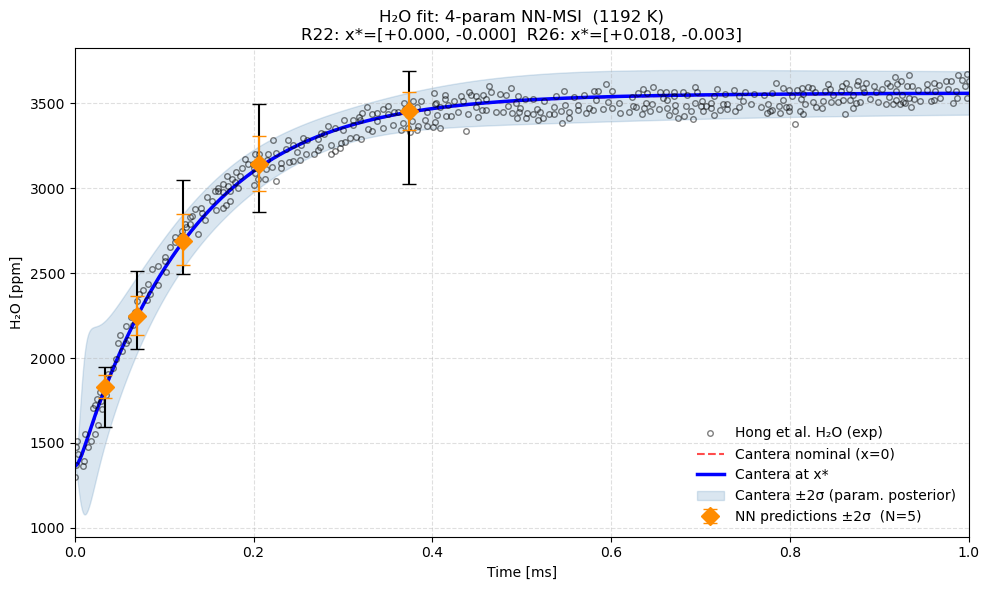

In [14]:
# ── Figure 1: H2O fit ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_h2o_raw, y_h2o_raw, 'o', mfc='none', mec='k', ms=4, alpha=0.5,
        zorder=3, label='Hong et al. H₂O (exp)')
ax.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
            yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
            fmt='none', ecolor='k', elinewidth=1.5, capsize=5, zorder=4,
            label='_nolegend_')
ax.plot(T_SIM * 1e3, h2o_nom * 1e6, 'r--', lw=1.5, alpha=0.7,
        label='Cantera nominal (x=0)')
ax.plot(T_SIM * 1e3, h2o_opt * 1e6, 'b-',  lw=2.5,
        label='Cantera at x*')
ax.fill_between(T_SIM * 1e3, h2o_lower * 1e6, h2o_upper * 1e6,
                color='steelblue', alpha=0.20,
                label='Cantera ±2σ (param. posterior)')
ax.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
            yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
            fmt='D', color='darkorange', ms=9, lw=1.5, capsize=5, zorder=7,
            label=f'NN predictions ±2σ  (N={N_TARGETS})')

ax.set_xlabel('Time [ms]')
ax.set_ylabel('H₂O [ppm]')
ax.set_xlim([0, 1.0])
ax.legend(loc='lower right', frameon=False)
ax.grid(True, ls='--', alpha=0.4)
ax.set_title(
    f'H₂O fit: 4-param NN-MSI  (1192 K)\n'
    f'R22: x*=[{x_opt[0]:+.3f}, {x_opt[1]:+.3f}]  '
    f'R26: x*=[{x_opt[2]:+.3f}, {x_opt[3]:+.3f}]')
plt.tight_layout()


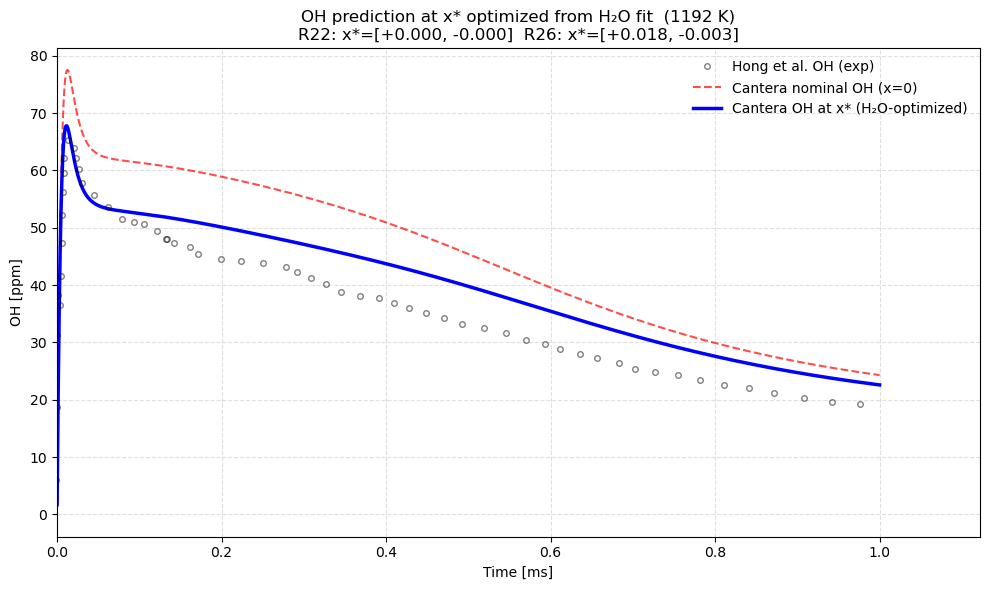

In [15]:
# ── Figure 2: OH comparison ───────────────────────────────────────────────────
# Determine x-axis limit from experimental OH data range
oh_xlim = max(t_oh_raw.max() * 1.15, 0.06)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_oh_raw, y_oh_raw, 'o', mfc='none', mec='k', ms=4, alpha=0.5,
        zorder=3, label='Hong et al. OH (exp)')
ax.plot(T_OH * 1e3, oh_nom * 1e6, 'r--', lw=1.5, alpha=0.7,
        label='Cantera nominal OH (x=0)')
ax.plot(T_OH * 1e3, oh_opt * 1e6, 'b-', lw=2.5,
        label='Cantera OH at x* (H₂O-optimized)')

ax.set_xlabel('Time [ms]')
ax.set_ylabel('OH [ppm]')
ax.set_xlim([0, oh_xlim])
ax.legend(loc='upper right', frameon=False)
ax.grid(True, ls='--', alpha=0.4)
ax.set_title(
    f'OH prediction at x* optimized from H₂O fit  (1192 K)\n'
    f'R22: x*=[{x_opt[0]:+.3f}, {x_opt[1]:+.3f}]  '
    f'R26: x*=[{x_opt[2]:+.3f}, {x_opt[3]:+.3f}]')
plt.tight_layout()


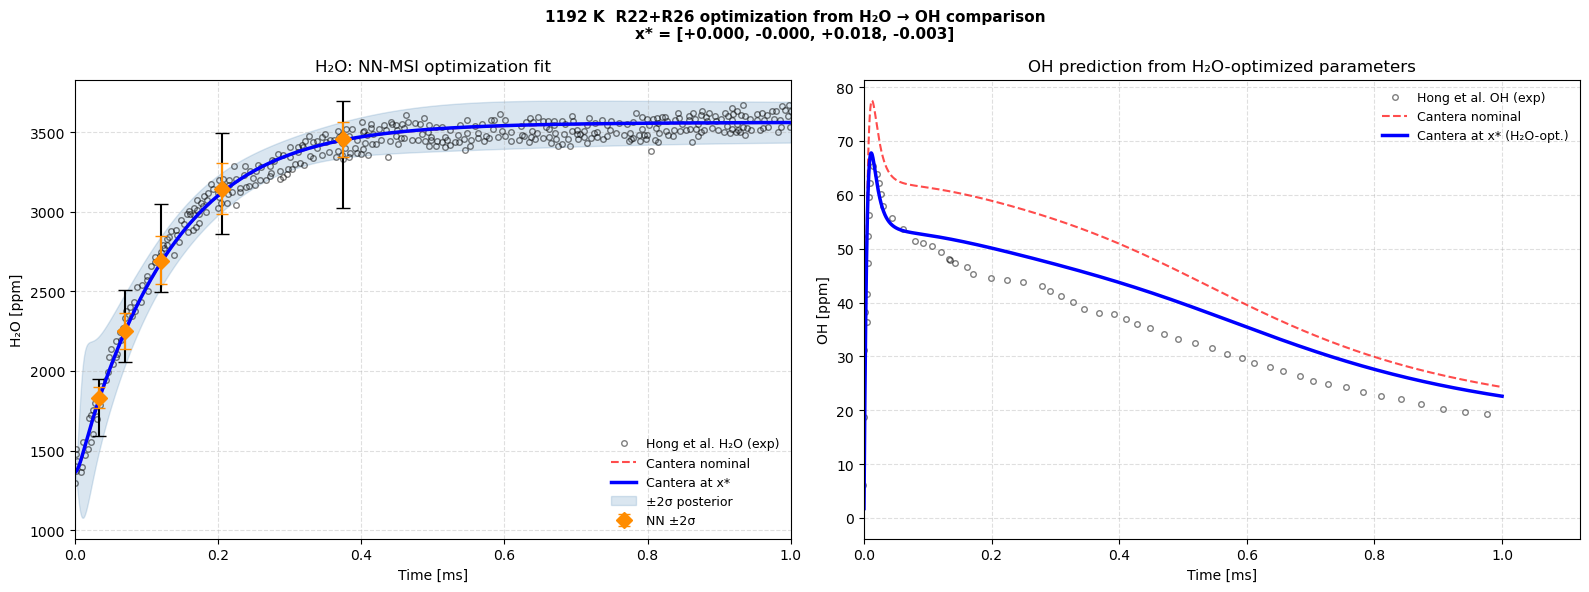

In [16]:
# ── Figure 3: combined (2-panel) ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# — H2O panel —
ax1.plot(t_h2o_raw, y_h2o_raw, 'o', mfc='none', mec='k', ms=4, alpha=0.5,
         label='Hong et al. H₂O (exp)')
ax1.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
             yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
             fmt='none', ecolor='k', elinewidth=1.5, capsize=5,
             label='_nolegend_')
ax1.plot(T_SIM * 1e3, h2o_nom * 1e6, 'r--', lw=1.5, alpha=0.7,
         label='Cantera nominal')
ax1.plot(T_SIM * 1e3, h2o_opt * 1e6, 'b-', lw=2.5,
         label='Cantera at x*')
ax1.fill_between(T_SIM * 1e3, h2o_lower * 1e6, h2o_upper * 1e6,
                 color='steelblue', alpha=0.20, label='±2σ posterior')
ax1.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
             yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
             fmt='D', color='darkorange', ms=8, lw=1.5, capsize=4, zorder=7,
             label='NN ±2σ')
ax1.set_xlabel('Time [ms]'); ax1.set_ylabel('H₂O [ppm]')
ax1.set_xlim([0, 1.0])
ax1.legend(frameon=False, fontsize=9)
ax1.grid(True, ls='--', alpha=0.4)
ax1.set_title('H₂O: NN-MSI optimization fit')

# — OH panel —
ax2.plot(t_oh_raw, y_oh_raw, 'o', mfc='none', mec='k', ms=4, alpha=0.5,
         label='Hong et al. OH (exp)')
ax2.plot(T_OH * 1e3, oh_nom * 1e6, 'r--', lw=1.5, alpha=0.7,
         label='Cantera nominal')
ax2.plot(T_OH * 1e3, oh_opt * 1e6, 'b-', lw=2.5,
         label='Cantera at x* (H₂O-opt.)')
ax2.set_xlabel('Time [ms]'); ax2.set_ylabel('OH [ppm]')
ax2.set_xlim([0, oh_xlim])
ax2.legend(frameon=False, fontsize=9)
ax2.grid(True, ls='--', alpha=0.4)
ax2.set_title('OH prediction from H₂O-optimized parameters')

plt.suptitle(
    f'1192 K  R22+R26 optimization from H₂O → OH comparison\n'
    f'x* = [{x_opt[0]:+.3f}, {x_opt[1]:+.3f}, {x_opt[2]:+.3f}, {x_opt[3]:+.3f}]',
    fontsize=11, fontweight='bold')
plt.tight_layout()

plt.show()
